# SegFormer + EfficientNet / MiT Collapse Investigation

## Problem Description

Some SegFormer encoder combinations showed a complete performance collapse in the `scratch-large` scenario:

- SegFormer + EfficientNet-B0/B1/B2/B3/B4
- SegFormer + MiT-B0/B1

Observed behavior:

- Test Dice ≈ 0.95 around epoch 10-12
- Test Dice ≈ 0 at the end of training
- Test IoU ≈ 0 at the end of training
- Test loss increased strongly
- Train loss in TensorBoard continued decreasing

At first glance, this looked like severe overfitting.

---

## Initial Hypotheses

Investigated:

1. Classical overfitting
2. Too many optimization steps due to larger dataset
3. SegFormer-specific optimization instability
4. All-background prediction collapse
5. Wrong checkpoint saving/loading
6. Train/eval mode differences
7. BatchNorm statistics corruption

---

## Findings

### 1. Final model predicts only background

For the affected models:

```text
Dice Loss = 1
Dice Score = 0
IoU = 0
```
for nearly all images

### 2. Best Checkpoint is completely fine

Example 
```text
Train Dice ≈ 0.97
Train IoU  ≈ 0.95
Loss       ≈ 0.02
```
Therefore:
- The architecture can solve the task.
- The problem appears later during training.

### 3. Huge discrepancy between train() and eval()

Final checkpoint:
```python
model.eval()
```
↓
```text
Train Dice ≈ 0
Test Dice  ≈ 0
```
but
```python
model.train()
```
↓
```text
Train Dice ≈ 0.97
Test Dice  ≈ 0.98
```
Therefore:
- The weights themselves are still good.
- Only evaluation mode is broken.

### 4. The problem is caused by the last BatchNorm layer

The cirtical layer is:
```text
decoder.fuse_stage.1
```
Setting only this layer to training mode.
```python
model.eval()

bn_layer = [m for m in model.modules() if isinstance(m, nn.BatchNorm2d)]

bn_layer[-1].train()
```
restores
```text
Train Dice ≈ 0.97
Test Dice  ≈ 0.98
```
Therefore:
- The failure is caused almost entirely by this single BatchNorm layer.

### 5. Running statistics explode

Example:

**EfficientNet-B0**

Best checkpoint:
```text
Running Mean = 23
Running Var  = 51
```
Final checkpoint:
```text
Running Mean = 2.732,094
Running Var  = 2,224,331
```

**MiT-B1**

Best checkpoint:
```text
Running Mean = 0.68
Running Var  = 25
```
Final Checkpoint:
```text
Running Mean = 32,019,240
Running Var  = 1,012,028
```
Working encoders (ResNet18, VGG11_BN, MobileOne) show much smaller chnges

---

## Conclusion

The observed collapse is **not classical overfitting**.

The final model still contains a good solution, as demonstrated by:
```python
model.train()
```
which achieves
```text
Train Dice ≈ 0.97
Test Dice  ≈ 0.98
```
The actual issue is:
```text
SegFormer decoder
    ↓
decoder.fuse_stage.1 BatchNorm
    ↓
running_mean / running_var explode
    ↓
eval() uses corrupted statistics
    ↓
all-background predictions
```
The phenomenon only appears for some SegFormer + encoder combinations because those encoders drive the decoder BatchNorm statistics into an unstble regime during prolonged training.


### Final interpretation
The apparent "overfitting" is primarily caused by corrupted BatchNorm running statistics in the final SegFormer decoder BatchNorm layer (*decoder.fuse_stage.1*), not by a loss of segmentation capability.

---

## Potential Paper Statement

Further analysis revealed that the apparent performance collapse was caused by corrupted running statistics in the final BatchNorm layer of the SegFormer decoder. Replacing the layer's evaluation statistics with batch statistics restored the original performance. The phenomenon was observed only for EfficientNet-B0-B4 and MiT-B0/B1 encoders, suggesting an interaction between encoder feature distributions and decoder normalization dynamics. The exact cause of this instability remains unclear and warrants future investigation.

In [2]:
# init model
from pathlib import Path
import numpy as np
import torch
import segmentation_models_pytorch as smp


def init_model(
    gpu = True,
    arch = "segformer",
    encoder = "efficientnet-b0",
    pretrained = "scratch-large",
    model_type = "final_model",
    path_to_models = Path(r"\\zvsl.mvl6.uni-tuebingen.de\Employees\06_Datasets\Bjoern\Segmentation\trained_models\AllScenarios\architecture_models")
    ):

    alias = {
        "unet": "unet",
        "u-net": "unet",
        "unet++": "unetplusplus",
        "unetplusplus": "unetplusplus",
        "deeplabv3+": "deeplabv3plus",
        "deeplabv3plus": "deeplabv3plus",
        "deeplab": "deeplabv3plus",
        "segformer": "segformer",
        "fpn": "fpn",
        "pspnet": "pspnet",
        "linknet": "linknet",
        "pan": "pan",
        "manet": "manet",
        "upernet": "upernet",
        "dpt": "dpt",
    }

    device = torch.device("cuda" if torch.cuda.is_available() and gpu else "cpu")
    
    model_name = f"{arch}_{encoder}_zscore_{pretrained}_{model_type}.pth"

    model_path = path_to_models / model_name
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")
    
    model = smp.create_model(
        arch = alias.get(arch, arch),
        encoder_name = encoder,
        in_channels=1,
        classes = 1,
        activation = None
    )

    model.to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))

    return model

if __name__ == "__main__":
    model = init_model()
    print(model)


Segformer(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Id

In [3]:
# init dataset
from pathlib import Path
import json
import dataset

path_to_experiment_logs = Path(r"logs\AllScenarios")
path_to_dataset = Path(r"F:\Python\SAM2\OCTDatasetOIMHS")
# path_to_dataset = Path(r"D:\Bjoern\Segmentation\datasets\OCTDatasetOIMHS")

with open(path_to_experiment_logs / "participant_split.json", "r") as f:
    participant_split = json.load(f)

train_dataset = dataset.OIMHSDataset(
    participants = participant_split["train"] + participant_split["pretrain"],
    path = path_to_dataset,
    augment = True,
    max_rotate_deg = 10,
    return_numpy = False,
    normalize = "zscore"
)

test_dataset = dataset.OIMHSDataset(
    participants = participant_split["test"],
    path = path_to_dataset,
    augment = False,
    max_rotate_deg = 0,
    return_numpy = False,
    normalize = "zscore"
)

print(f"Train dataset length: {len(train_dataset)}")

print(f"Test dataset length: {len(test_dataset)}")

Train dataset length: 2616
Test dataset length: 1243


In [4]:
participant_split.keys()

dict_keys(['train', 'pretrain', 'test'])

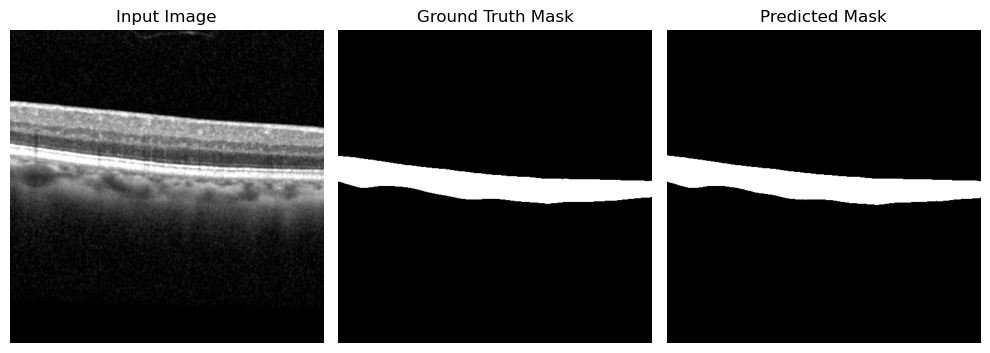

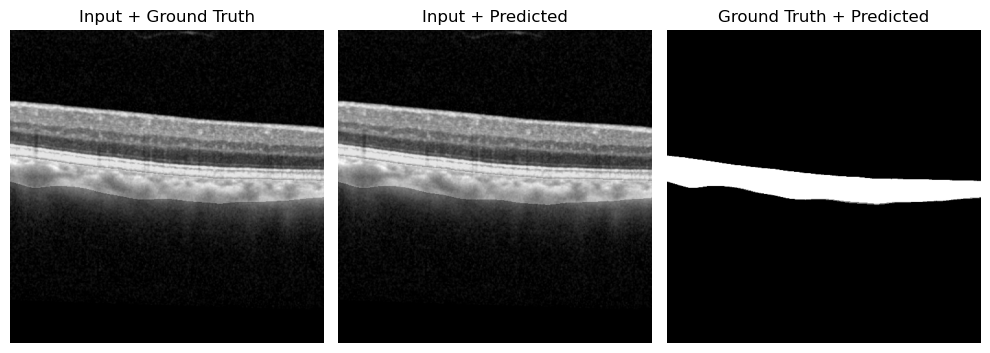

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

model = init_model(
    gpu = True,
    arch = "segformer",
    encoder = "resnet18",
    pretrained = "scratch-large",
    model_type = "final_model"
)
model.eval()


device = next(model.parameters()).device

img, mask = test_dataset[20]

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()


img_np = img.squeeze().cpu().numpy()
mask_np = mask.squeeze().cpu().numpy()
preds_np = preds.squeeze().cpu().numpy()

fig, axs = plt.subplots(1, 3, figsize=(10, 5))


axs[0].imshow(img_np, cmap="gray")
axs[0].set_title("Input Image")
axs[0].axis("off")

axs[1].imshow(mask_np, cmap="gray")
axs[1].set_title("Ground Truth Mask")
axs[1].axis("off")

axs[2].imshow(preds_np, cmap="gray")
axs[2].set_title("Predicted Mask")
axs[2].axis("off")

plt.tight_layout()
plt.show()


img_rgb = np.repeat(img_np[..., np.newaxis], 3, axis=-1)

overlay_input_gt = img_np * 0.5 + mask_np * 0.5
overlay_input_pred = img_np * 0.5 + preds_np * 0.5
overlay_gt_pred = mask_np * 0.5 + preds_np * 0.5

fig, axs = plt.subplots(1, 3, figsize=(10, 5))

axs[0].imshow(overlay_input_gt, cmap="gray")
axs[0].set_title("Input + Ground Truth")
axs[0].axis("off")

axs[1].imshow(overlay_input_pred, cmap="gray")
axs[1].set_title("Input + Predicted")
axs[1].axis("off")

axs[2].imshow(overlay_gt_pred, cmap="gray")
axs[2].set_title("Ground Truth + Predicted")
axs[2].axis("off")


plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import torch
import segmentation_models_pytorch as smp

def calculate_loss_metrics(logits, mask):
    bce_loss = torch.nn.BCEWithLogitsLoss()(logits, mask)
    dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)(logits, mask)



    total_loss = 0.5 * bce_loss + 0.5 * dice_loss



    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()



    preds_f = preds.view(1, -1)
    masks_f = mask.view(1, -1)



    intersection = (preds_f * masks_f).sum()
    pred_sum = preds_f.sum()
    mask_sum = masks_f.sum()



    union = pred_sum + mask_sum - intersection



    dice_score = (2. * intersection) / (pred_sum + mask_sum)
    iou_score = intersection / union if union > 0 else torch.tensor(0.0)



    return total_loss.item(), bce_loss.item(), dice_loss.item(), dice_score.item(), iou_score.item()

In [7]:
import dataset
import numpy as np
import torch
import segmentation_models_pytorch as smp
from tqdm import tqdm


model = init_model(
    gpu = True,
    arch = "segformer",
    encoder = "efficientnet-b0",
    pretrained = "scratch-large",
    model_type = "final_model"
)
model.eval()

device = next(model.parameters()).device

train_loader, test_loader = dataset.get_dataloader(
    train_participants = participant_split["train"] + participant_split["pretrain"],
    test_participants = participant_split["test"],
    path = path_to_dataset,
    augment = False,
    max_rotate_deg = 0,
    hflip_p = 0,
    return_numpy = False,
    normalize = "zscore",
    batch_size = 8,
    num_workers = 0
)

running_loss = 0.0
n = 0

bce = torch.nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode="binary", from_logits=True)  # [6](https://segmentation-models-pytorch.readthedocs.io/en/latest/losses.html)[7](https://segmentation-models-pytorch.readthedocs.io/en/latest/_modules/segmentation_models_pytorch/losses/dice.html)

def loss_fn(logits, masks):
    return 0.5 * bce(logits, masks) + 0.5 * dice(logits, masks)

with torch.no_grad():
    for images, masks in tqdm(test_loader):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = loss_fn(logits, masks)

        running_loss += loss.item() * images.size(0)
        n += images.size(0)

print(f"Average Loss on Train Set: {running_loss / n}")

100%|██████████| 156/156 [00:42<00:00,  3.64it/s]

Average Loss on Train Set: 11.042824998366095


In [8]:
import numpy as np
import torch
import pandas as pd
from tqdm import tqdm



model = init_model(
    gpu = True,
    arch = "segformer",
    encoder = "efficientnet-b0",
    pretrained = "scratch-large",
    model_type = "final_model"
)
model.eval()




device = next(model.parameters()).device



# img, mask = test_dataset[20]
# img, mask = train_dataset[30]



results = []



for img, mask in tqdm(train_dataset):
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))




    loss, bce_loss, dice_loss, dice_score, iou_score = calculate_loss_metrics(logits, mask.unsqueeze(0).to(device))
    results.append({
        "loss": loss,
        "bce_loss": bce_loss,
        "dice_loss": dice_loss,
        "dice_score": dice_score,
        "iou_score": iou_score
    })

results_df_segformer_eval_onTrain = pd.DataFrame(results)
results_df_segformer_eval_onTrain.describe()

100%|██████████| 2616/2616 [02:45<00:00, 15.80it/s]


,loss,bce_loss,dice_loss,dice_score,iou_score
count,2616.000000,2616.000000,2616.0,2616.0,2616.0
mean,10.096019,19.192037,1.0,0.0,0.0
std,3.372740,6.745481,0.0,0.0,0.0
min,3.375686,5.751372,1.0,0.0,0.0
25%,7.686399,14.372798,1.0,0.0,0.0
50%,9.512008,18.024016,1.0,0.0,0.0
75%,12.013524,23.027049,1.0,0.0,0.0
max,22.262171,43.524342,1.0,0.0,0.0


In [9]:
import numpy as np
import torch
import pandas as pd
from tqdm import tqdm



model = init_model(
    gpu = True,
    arch = "segformer",
    encoder = "efficientnet-b0",
    pretrained = "scratch-large",
    model_type = "final_model"
)
model.train()




device = next(model.parameters()).device



# img, mask = test_dataset[20]
# img, mask = train_dataset[30]



results = []



for img, mask in tqdm(train_dataset):
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))




    loss, bce_loss, dice_loss, dice_score, iou_score = calculate_loss_metrics(logits, mask.unsqueeze(0).to(device))
    results.append({
        "loss": loss,
        "bce_loss": bce_loss,
        "dice_loss": dice_loss,
        "dice_score": dice_score,
        "iou_score": iou_score
    })

results_df_segformer_train_onTrain = pd.DataFrame(results)
results_df_segformer_train_onTrain.describe()

100%|██████████| 2616/2616 [02:24<00:00, 18.11it/s]


,loss,bce_loss,dice_loss,dice_score,iou_score
count,2616.000000,2616.000000,2616.000000,2616.000000,2616.000000
mean,0.025691,0.021037,0.030344,0.971610,0.946040
std,0.027835,0.030192,0.028019,0.027783,0.046599
min,0.005900,0.003109,0.007913,0.553957,0.383085
25%,0.012501,0.007835,0.016606,0.969066,0.939989
50%,0.017415,0.012251,0.022021,0.979800,0.960399
75%,0.028058,0.021516,0.032819,0.985121,0.970678
max,0.430882,0.408589,0.453175,0.993719,0.987516


In [10]:
import numpy as np
import torch
import pandas as pd
from tqdm import tqdm



model = init_model(
    gpu = True,
    arch = "segformer",
    encoder = "efficientnet-b0",
    pretrained = "scratch-large",
    model_type = "best_model"
)
model.eval()




device = next(model.parameters()).device



# img, mask = test_dataset[20]
# img, mask = train_dataset[30]



results = []



for img, mask in tqdm(train_dataset):
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))




    loss, bce_loss, dice_loss, dice_score, iou_score = calculate_loss_metrics(logits, mask.unsqueeze(0).to(device))
    results.append({
        "loss": loss,
        "bce_loss": bce_loss,
        "dice_loss": dice_loss,
        "dice_score": dice_score,
        "iou_score": iou_score
    })

results_df_segformer_best_eval_onTrain = pd.DataFrame(results)
results_df_segformer_best_eval_onTrain.describe()

100%|██████████| 2616/2616 [02:09<00:00, 20.14it/s]


,loss,bce_loss,dice_loss,dice_score,iou_score
count,2616.000000,2616.000000,2616.000000,2616.000000,2616.000000
mean,0.023439,0.014932,0.031947,0.971861,0.945964
std,0.017242,0.015097,0.021384,0.020506,0.035387
min,0.007867,0.003210,0.010687,0.575613,0.404112
25%,0.014553,0.007454,0.020467,0.968754,0.939401
50%,0.018638,0.010838,0.025791,0.977750,0.956468
75%,0.026175,0.016653,0.035496,0.982591,0.965778
max,0.351537,0.272651,0.430422,0.991074,0.982306


In [11]:

import torch.nn as nn



def show_bn_stats(model):
    model.eval()
    for name, module in model.named_modules():
        if isinstance(module, nn.BatchNorm2d):
            print(f"BatchNorm Layer: {name}")
            print(f"Running Mean: {module.running_mean.mean().item()}")
            print(f"Running Var: {module.running_var.mean().item()}")
            print("-" * 50)



model_seg = init_model(
    gpu = True,
    arch = "segformer",
    encoder = "efficientnet-b0",
    pretrained = "scratch-large",
    model_type = "final_model"
)



model_seg_best = init_model(
    gpu = True,
    arch = "segformer",
    encoder = "efficientnet-b0",
    pretrained = "scratch-large",
    model_type = "best_model"
)





model_resnet = init_model(
    gpu = True,
    arch = "segformer",
    encoder = "resnet18",
    pretrained = "scratch-large",
    model_type = "final_model"
)



print("Segformer Model Summary:")
print()
print()
show_bn_stats(model_seg)



print()
print("=" * 50)
print()



print("Segformer Best Model Summary:")
print()
print()
show_bn_stats(model_seg_best)



print()
print("=" * 50)
print()



print("ResNet Model Summary:")
print()
print()
show_bn_stats(model_resnet)

Segformer Model Summary:


BatchNorm Layer: encoder._bn0
Running Mean: -0.0003604135708883405
Running Var: 0.6184346079826355
--------------------------------------------------
BatchNorm Layer: encoder._blocks.0._bn1
Running Mean: -0.035838782787323
Running Var: 0.17724797129631042
--------------------------------------------------
BatchNorm Layer: encoder._blocks.0._bn2
Running Mean: 0.0013230196200311184
Running Var: 0.07903130352497101
--------------------------------------------------
BatchNorm Layer: encoder._blocks.1._bn0
Running Mean: -0.0037400610744953156
Running Var: 0.6760144233703613
--------------------------------------------------
BatchNorm Layer: encoder._blocks.1._bn1
Running Mean: -0.00761680630967021
Running Var: 0.18839994072914124
--------------------------------------------------
BatchNorm Layer: encoder._blocks.1._bn2
Running Mean: 0.02164558693766594
Running Var: 0.17650464177131653
--------------------------------------------------
BatchNorm Layer: encoder._blo

In [12]:

def show_last_batchnorm_stats(model):
    model.eval()
    list_batchnorms = [(name, model) for name, model in model.named_modules() if isinstance(model, nn.BatchNorm2d)]
    name, model = list_batchnorms[-1]
    print(f"Last BatchNorm Layer: {name}")
    print(f"Running Mean: {model.running_mean.mean().item()}")
    print(f"Running Var: {model.running_var.mean().item()}")



model_seg = init_model(
    gpu = True,
    arch = "segformer",
    encoder = "efficientnet-b0",
    pretrained = "scratch-large",
    model_type = "final_model"
)



encoders = ["efficientnet-b0", "efficientnet-b1", "efficientnet-b2", "efficientnet-b3", "efficientnet-b4", 
            "mit_b0", "mit_b1", "resnet18", "vgg11_bn", "mobileone_s1"]



for encoder in encoders:
    model = init_model(
        gpu = True,
        arch = "segformer",
        encoder = encoder,
        pretrained = "scratch-large",
        model_type = "final_model"
    )
    print(f"Encoder: {encoder}")
    print("-" * 50)    
    print("Final state")
    show_last_batchnorm_stats(model)



    model = init_model(
            gpu = True,
            arch = "segformer",
            encoder = encoder,
            pretrained = "scratch-large",
            model_type = "best_model"
        )
    print("-" * 50)
    print("Best state")
    show_last_batchnorm_stats(model)
    print("=" * 50)

Encoder: efficientnet-b0
--------------------------------------------------
Final state
Last BatchNorm Layer: decoder.fuse_stage.1
Running Mean: 2732094.0
Running Var: 2224331.0
--------------------------------------------------
Best state
Last BatchNorm Layer: decoder.fuse_stage.1
Running Mean: 23.273845672607422
Running Var: 50.79401397705078
Encoder: efficientnet-b1
--------------------------------------------------
Final state
Last BatchNorm Layer: decoder.fuse_stage.1
Running Mean: 2687115.5
Running Var: 1461982.25
--------------------------------------------------
Best state
Last BatchNorm Layer: decoder.fuse_stage.1
Running Mean: 2447.373291015625
Running Var: 4151.6396484375
Encoder: efficientnet-b2
--------------------------------------------------
Final state
Last BatchNorm Layer: decoder.fuse_stage.1
Running Mean: 6239131.0
Running Var: 2344020.0
--------------------------------------------------
Best state
Last BatchNorm Layer: decoder.fuse_stage.1
Running Mean: 1842.547729